<a href="https://colab.research.google.com/github/Bhavninder/HR-Analytics-PBL/blob/main/HR_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels xgboost shap -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import shap

In [ ]:
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


In [ ]:
# Check if files are uploaded
import os

files = os.listdir()
print("Files in current directory:")
for f in files:
    if f.endswith('.csv'):
        print(f"  ✓ {f}")

# Set file paths
DS_SALARIES_FILE = 'ds_salaries.csv'
SO_SURVEY_FILE = 'survey_results_public.csv'

if os.path.exists(DS_SALARIES_FILE) and os.path.exists(SO_SURVEY_FILE):
    print("\n✓ Both datasets found! Ready to proceed.")
else:
    print("\n⚠ WARNING: Please upload the CSV files first!")

Files in current directory:
  ✓ survey_results_public.csv
  ✓ ds_salaries.csv

✓ Both datasets found! Ready to proceed.


In [ ]:
print("\n" + "="*80)
print("DATASET 1: KAGGLE DS SALARIES - OVERVIEW")
print("="*80)

print("\nFirst 5 rows:")
display(ds_salaries.head())

print("\nData Info:")
ds_salaries.info()

print("\nBasic Statistics:")
display(ds_salaries.describe())

print("\nMissing Values:")
missing = ds_salaries.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values!")
else:
    print(missing[missing > 0])


DATASET 1: KAGGLE DS SALARIES - OVERVIEW

First 5 rows:


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB

Basic Statistics:


,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000



Missing Values:
✓ No missing values!


In [ ]:
print("\n" + "="*80)
print("DATASET 2: STACK OVERFLOW SURVEY - FILTERING")
print("="*80)
so_data = so_survey[
    (so_survey['ConvertedCompYearly'].notna()) &
    (so_survey['DevType'].notna()) &
    (so_survey['DevType'].str.contains('Data|data|Scientist|scientist|Analyst|analyst|AI|Machine|machine',
                                       na=False, case=False))
].copy()

print(f"\nOriginal survey size: {len(so_survey):,} responses")
print(f"Filtered data professionals: {len(so_data):,} records")
print(f"Filter rate: {len(so_data)/len(so_survey)*100:.1f}%")

print("\nFirst 5 rows (key columns):")
key_cols = ['Age', 'EdLevel', 'DevType', 'Country', 'ConvertedCompYearly']
display(so_data[key_cols].head())


DATASET 2: STACK OVERFLOW SURVEY - FILTERING

Original survey size: 16,423 responses
Filtered data professionals: 699 records
Filter rate: 4.3%

First 5 rows (key columns):


,Age,EdLevel,DevType,Country,ConvertedCompYearly
8,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Data engineer,Ukraine,70000.0
16,65 years or older,Some college/university study without earning ...,Financial analyst or engineer,Australia,16252.0
33,45-54 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Data engineer,United States of America,175000.0
45,45-54 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",AI/ML engineer,Hungary,80966.0
68,45-54 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Data engineer,France,174022.0


In [ ]:
print("\n" + "="*80)
print("QUICK COMPARISON")
print("="*80)

comparison = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Min Salary (USD)',
        'Max Salary (USD)',
        'Mean Salary (USD)',
        'Median Salary (USD)'
    ],
    'Dataset 1 (Kaggle)': [
        len(ds_salaries),
        f"${ds_salaries['salary_in_usd'].min():,.0f}",
        f"${ds_salaries['salary_in_usd'].max():,.0f}",
        f"${ds_salaries['salary_in_usd'].mean():,.0f}",
        f"${ds_salaries['salary_in_usd'].median():,.0f}"
    ],
    'Dataset 2 (Stack Overflow)': [
        len(so_data),
        f"${so_data['ConvertedCompYearly'].min():,.0f}",
        f"${so_data['ConvertedCompYearly'].max():,.0f}",
        f"${so_data['ConvertedCompYearly'].mean():,.0f}",
        f"${so_data['ConvertedCompYearly'].median():,.0f}"
    ]
})

display(comparison)

print("\n✓ STEP 1 COMPLETE!")


QUICK COMPARISON


,Metric,Dataset 1 (Kaggle),Dataset 2 (Stack Overflow)
0,Total Records,607,699
1,Min Salary (USD),"$2,859",$1
2,Max Salary (USD),"$600,000","$4,706,124"
3,Mean Salary (USD),"$112,298","$111,487"
4,Median Salary (USD),"$101,570","$85,557"



✓ STEP 1 COMPLETE!


In [ ]:
print("="*80)
print("STEP 2: DATA CLEANING & PREPROCESSING")
print("="*80)

# Create copies
ds_clean = ds_salaries.copy()
so_clean = so_data.copy()

print("\nCreated working copies of both datasets")

STEP 2: DATA CLEANING & PREPROCESSING

Created working copies of both datasets


In [ ]:
# Clean Dataset 1
print("\n" + "-"*80)
print("CLEANING DATASET 1: KAGGLE DS SALARIES")
print("-"*80)

# Drop unnamed column
if 'Unnamed: 0' in ds_clean.columns:
    ds_clean = ds_clean.drop('Unnamed: 0', axis=1)
    print("✓ Dropped 'Unnamed: 0' column")

# Remove duplicates
duplicates = ds_clean.duplicated().sum()
if duplicates > 0:
    ds_clean = ds_clean.drop_duplicates()
    print(f"✓ Removed {duplicates} duplicate rows")
else:
    print("✓ No duplicates found")

# Remove extreme outliers (salary < $5k)
before = len(ds_clean)
ds_clean = ds_clean[ds_clean['salary_in_usd'] >= 5000]
removed = before - len(ds_clean)
if removed > 0:
    print(f"✓ Removed {removed} records with salary < $5,000")

print(f"\nDataset 1 after cleaning: {len(ds_clean)} records")


--------------------------------------------------------------------------------
CLEANING DATASET 1: KAGGLE DS SALARIES
--------------------------------------------------------------------------------
✓ Dropped 'Unnamed: 0' column
✓ Removed 42 duplicate rows
✓ Removed 3 records with salary < $5,000

Dataset 1 after cleaning: 562 records


In [ ]:
# Create derived features for Dataset 1
print("\n" + "-"*80)
print("CREATING DERIVED FEATURES - DATASET 1")
print("-"*80)

# 1. Experience level numeric mapping
experience_mapping = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
ds_clean['experience_level_numeric'] = ds_clean['experience_level'].map(experience_mapping)
print("✓ Created experience_level_numeric (1-4)")

# 2. Company size numeric mapping
company_size_mapping = {'S': 1, 'M': 2, 'L': 3}
ds_clean['company_size_numeric'] = ds_clean['company_size'].map(company_size_mapping)
print("✓ Created company_size_numeric (1-3)")

# 3. Remote category
ds_clean['remote_category'] = ds_clean['remote_ratio'].apply(
    lambda x: 'On-site' if x == 0 else ('Hybrid' if x == 50 else 'Fully Remote')
)
print("✓ Created remote_category (On-site/Hybrid/Fully Remote)")

# 4. Geographic regions
def classify_region(country):
    north_america = ['US', 'CA', 'MX']
    europe = ['GB', 'DE', 'FR', 'ES', 'IT', 'NL', 'CH', 'PT', 'PL', 'GR',
              'BE', 'AT', 'SE', 'IE', 'DK', 'NO', 'FI', 'CZ', 'RO']
    asia = ['IN', 'JP', 'CN', 'SG', 'KR', 'PK', 'PH', 'TH', 'VN', 'ID', 'MY']
    south_america = ['BR', 'AR', 'CL', 'CO', 'PE']
    oceania = ['AU', 'NZ']

    if country in north_america:
        return 'North America'
    elif country in europe:
        return 'Europe'
    elif country in asia:
        return 'Asia'
    elif country in south_america:
        return 'South America'
    elif country in oceania:
        return 'Oceania'
    else:
        return 'Other'

ds_clean['region'] = ds_clean['company_location'].apply(classify_region)
print("✓ Created region (geographic grouping)")

# 5. Salary bands
def classify_salary_band(salary):
    if salary < 50000:
        return 'Entry (<50k)'
    elif salary < 100000:
        return 'Mid (50k-100k)'
    elif salary < 150000:
        return 'Senior (100k-150k)'
    else:
        return 'Executive (>150k)'

ds_clean['salary_band'] = ds_clean['salary_in_usd'].apply(classify_salary_band)
print("✓ Created salary_band (Entry/Mid/Senior/Executive)")

print(f"\nTotal columns in Dataset 1: {len(ds_clean.columns)}")


--------------------------------------------------------------------------------
CREATING DERIVED FEATURES - DATASET 1
--------------------------------------------------------------------------------
✓ Created experience_level_numeric (1-4)
✓ Created company_size_numeric (1-3)
✓ Created remote_category (On-site/Hybrid/Fully Remote)
✓ Created region (geographic grouping)
✓ Created salary_band (Entry/Mid/Senior/Executive)

Total columns in Dataset 1: 16


In [ ]:
# Clean Dataset 2
print("\n" + "-"*80)
print("CLEANING DATASET 2: STACK OVERFLOW SURVEY")
print("-"*80)

# Remove extreme outliers
print("\nSalary before cleaning:")
print(so_clean['ConvertedCompYearly'].describe())

before_so = len(so_clean)
so_clean = so_clean[
    (so_clean['ConvertedCompYearly'] >= 5000) &
    (so_clean['ConvertedCompYearly'] <= 500000)
]
removed_so = before_so - len(so_clean)
print(f"\n✓ Removed {removed_so} outlier records")

print("\nSalary after cleaning:")
print(so_clean['ConvertedCompYearly'].describe())

# Handle missing values
critical_cols = ['ConvertedCompYearly', 'DevType']
so_clean = so_clean.dropna(subset=critical_cols)
print(f"\n✓ Records after dropping critical missing values: {len(so_clean)}")

# Fill WorkExp missing values
if 'WorkExp' in so_clean.columns:
    try:
        so_clean['WorkExp'] = pd.to_numeric(so_clean['WorkExp'], errors='coerce')
        median_exp = so_clean['WorkExp'].median()
        so_clean['WorkExp'].fillna(median_exp, inplace=True)
        print(f"✓ Filled WorkExp missing values with median: {median_exp}")
    except:
        print("✓ WorkExp kept as categorical")

print(f"\nDataset 2 after cleaning: {len(so_clean)} records")


--------------------------------------------------------------------------------
CLEANING DATASET 2: STACK OVERFLOW SURVEY
--------------------------------------------------------------------------------

Salary before cleaning:
count    6.990000e+02
mean     1.114871e+05
std      2.099747e+05
min      1.000000e+00
25%      4.931300e+04
50%      8.555700e+04
75%      1.392180e+05
max      4.706124e+06
Name: ConvertedCompYearly, dtype: float64

✓ Removed 41 outlier records

Salary after cleaning:
count       658.000000
mean     105658.869301
std       74106.229857
min        5097.000000
25%       54638.000000
50%       88331.500000
75%      140226.000000
max      500000.000000
Name: ConvertedCompYearly, dtype: float64

✓ Records after dropping critical missing values: 658
✓ Filled WorkExp missing values with median: 10.0

Dataset 2 after cleaning: 658 records


In [ ]:
# Summary after cleaning
print("\n" + "="*80)
print("CLEANING SUMMARY")
print("="*80)

summary = pd.DataFrame({
    'Metric': [
        'Records After Cleaning',
        'Mean Salary (USD)',
        'Median Salary (USD)',
        'Std Dev Salary'
    ],
    'Dataset 1 (Kaggle)': [
        len(ds_clean),
        f"${ds_clean['salary_in_usd'].mean():,.0f}",
        f"${ds_clean['salary_in_usd'].median():,.0f}",
        f"${ds_clean['salary_in_usd'].std():,.0f}"
    ],
    'Dataset 2 (Stack Overflow)': [
        len(so_clean),
        f"${so_clean['ConvertedCompYearly'].mean():,.0f}",
        f"${so_clean['ConvertedCompYearly'].median():,.0f}",
        f"${so_clean['ConvertedCompYearly'].std():,.0f}"
    ]
})

display(summary)

print("\n✓ STEP 2 COMPLETE!")


CLEANING SUMMARY


,Metric,Dataset 1 (Kaggle),Dataset 2 (Stack Overflow)
0,Records After Cleaning,562,658
1,Mean Salary (USD),"$111,181","$105,659"
2,Median Salary (USD),"$100,000","$88,332"
3,Std Dev Salary,"$72,048","$74,106"



✓ STEP 2 COMPLETE!


In [ ]:
print("="*80)
print("STEP 3: EXPLORATORY DATA ANALYSIS")
print("="*80)

# Set figure size for all plots
plt.rcParams['figure.figsize'] = (12, 6)

STEP 3: EXPLORATORY DATA ANALYSIS



3.1 SALARY DISTRIBUTION
--------------------------------------------------------------------------------


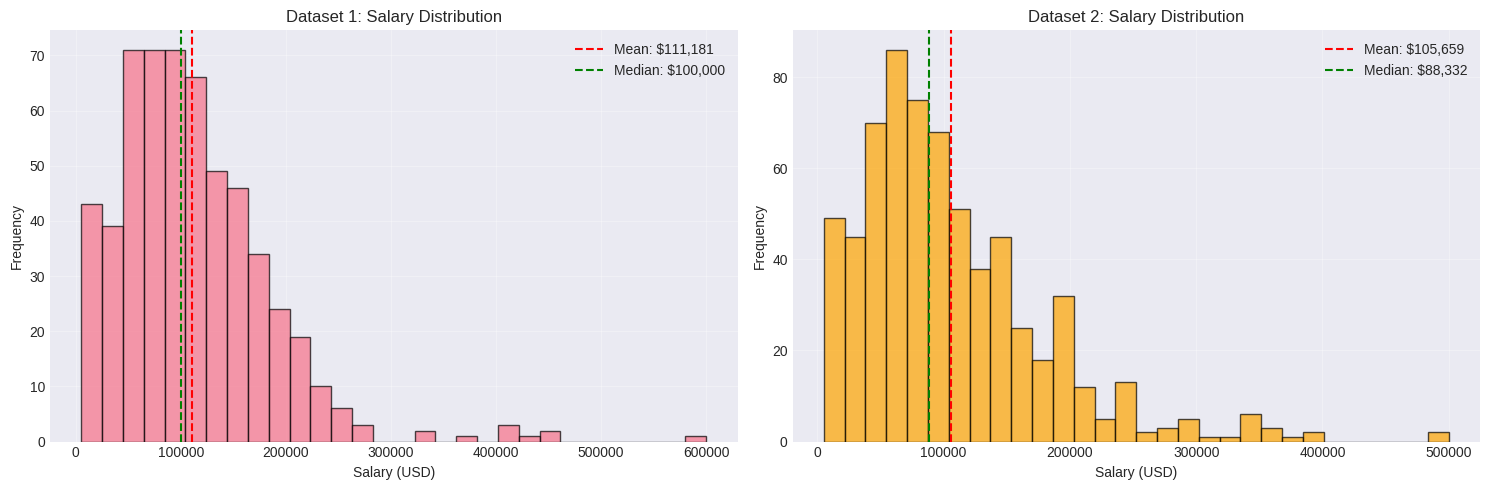

✓ Saved: salary_distribution.png


In [ ]:
# 3.1 Salary Distribution
print("\n3.1 SALARY DISTRIBUTION")
print("-"*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Dataset 1
axes[0].hist(ds_clean['salary_in_usd'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(ds_clean['salary_in_usd'].mean(), color='red', linestyle='--',
                label=f"Mean: ${ds_clean['salary_in_usd'].mean():,.0f}")
axes[0].axvline(ds_clean['salary_in_usd'].median(), color='green', linestyle='--',
                label=f"Median: ${ds_clean['salary_in_usd'].median():,.0f}")
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Dataset 1: Salary Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dataset 2
axes[1].hist(so_clean['ConvertedCompYearly'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(so_clean['ConvertedCompYearly'].mean(), color='red', linestyle='--',
                label=f"Mean: ${so_clean['ConvertedCompYearly'].mean():,.0f}")
axes[1].axvline(so_clean['ConvertedCompYearly'].median(), color='green', linestyle='--',
                label=f"Median: ${so_clean['ConvertedCompYearly'].median():,.0f}")
axes[1].set_xlabel('Salary (USD)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Dataset 2: Salary Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('salary_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: salary_distribution.png")


3.2 SALARY BY EXPERIENCE LEVEL
--------------------------------------------------------------------------------


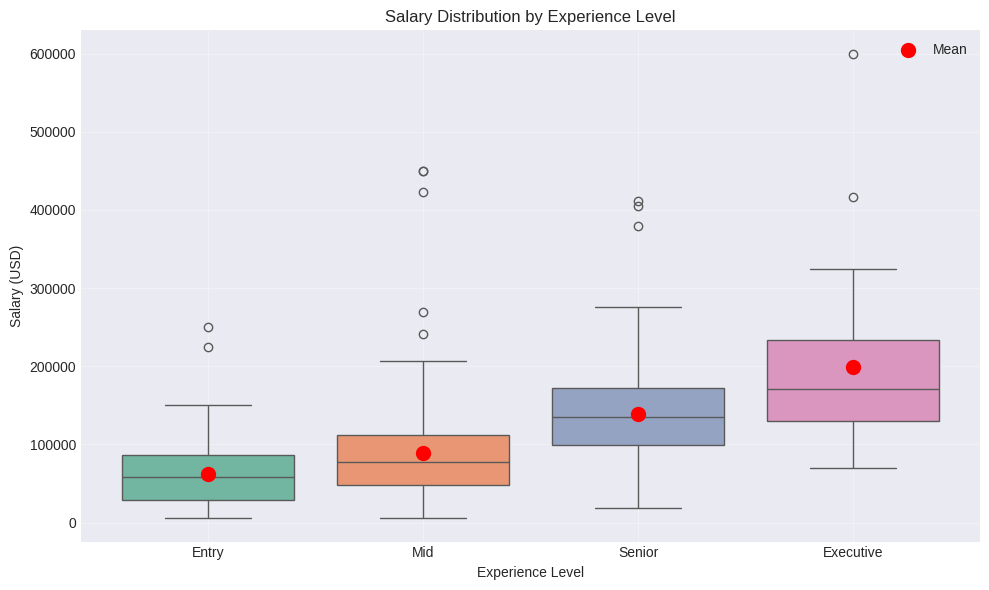


Mean Salary by Experience Level:


,mean,median,count
experience_level,,,
EN,62305.885057,58000.0,87
EX,199392.038462,171437.5,26
MI,88612.058252,76949.0,206
SE,138374.880658,135000.0,243



✓ Saved: salary_by_experience.png


In [ ]:
# 3.2 Salary by Experience Level
print("\n3.2 SALARY BY EXPERIENCE LEVEL")
print("-"*80)

fig, ax = plt.subplots(figsize=(10, 6))

# Box plot
exp_order = ['EN', 'MI', 'SE', 'EX']
sns.boxplot(data=ds_clean, x='experience_level', y='salary_in_usd',
            order=exp_order, palette='Set2', ax=ax)
ax.set_xlabel('Experience Level')
ax.set_ylabel('Salary (USD)')
ax.set_title('Salary Distribution by Experience Level')
ax.set_xticklabels(['Entry', 'Mid', 'Senior', 'Executive'])
ax.grid(True, alpha=0.3)

# Add mean markers
means = ds_clean.groupby('experience_level')['salary_in_usd'].mean()
positions = range(len(exp_order))
ax.scatter(positions, [means[exp] for exp in exp_order],
           color='red', s=100, zorder=5, label='Mean')
ax.legend()

plt.tight_layout()
plt.savefig('salary_by_experience.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("\nMean Salary by Experience Level:")
display(ds_clean.groupby('experience_level')['salary_in_usd'].agg(['mean', 'median', 'count']))

print("\n✓ Saved: salary_by_experience.png")


3.3 SALARY BY COMPANY SIZE
--------------------------------------------------------------------------------


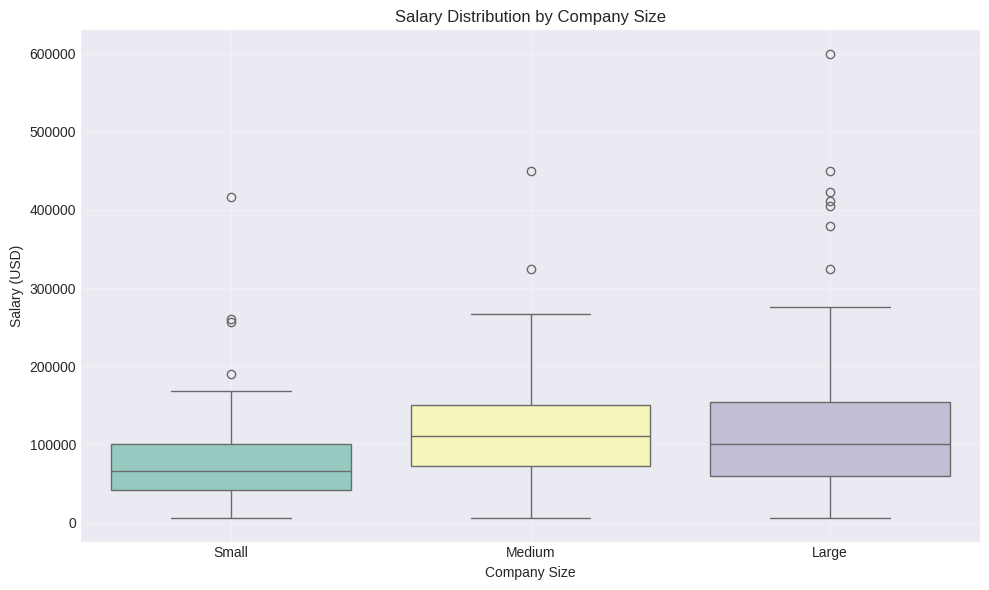


Mean Salary by Company Size:


,mean,median,count
company_size,,,
L,118213.880829,100000.0,193
M,115576.572917,110250.0,288
S,78798.185185,66022.0,81



✓ Saved: salary_by_company_size.png


In [ ]:
# 3.3 Salary by Company Size
print("\n3.3 SALARY BY COMPANY SIZE")
print("-"*80)

fig, ax = plt.subplots(figsize=(10, 6))

size_order = ['S', 'M', 'L']
sns.boxplot(data=ds_clean, x='company_size', y='salary_in_usd',
            order=size_order, palette='Set3', ax=ax)
ax.set_xlabel('Company Size')
ax.set_ylabel('Salary (USD)')
ax.set_title('Salary Distribution by Company Size')
ax.set_xticklabels(['Small', 'Medium', 'Large'])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('salary_by_company_size.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMean Salary by Company Size:")
display(ds_clean.groupby('company_size')['salary_in_usd'].agg(['mean', 'median', 'count']))

print("\n✓ Saved: salary_by_company_size.png")


3.4 SALARY BY REMOTE WORK
--------------------------------------------------------------------------------


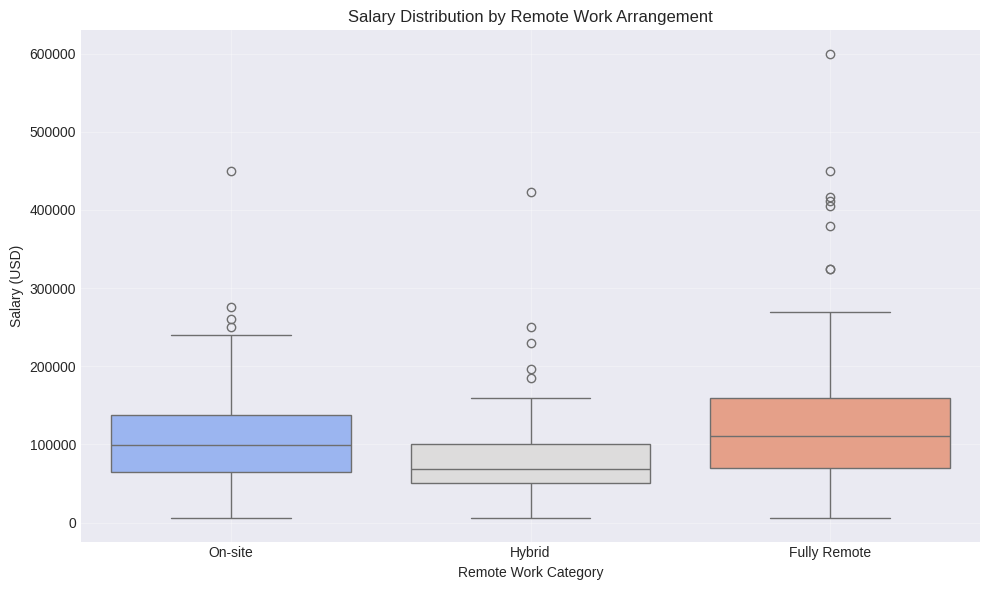


Mean Salary by Remote Category:


,mean,median,count
remote_category,,,
Fully Remote,121101.634783,110925.0,345
Hybrid,80721.897959,68010.5,98
On-site,107505.672269,99000.0,119



✓ Saved: salary_by_remote.png


In [ ]:
# 3.4 Salary by Remote Ratio
print("\n3.4 SALARY BY REMOTE WORK")
print("-"*80)

fig, ax = plt.subplots(figsize=(10, 6))

remote_order = ['On-site', 'Hybrid', 'Fully Remote']
sns.boxplot(data=ds_clean, x='remote_category', y='salary_in_usd',
            order=remote_order, palette='coolwarm', ax=ax)
ax.set_xlabel('Remote Work Category')
ax.set_ylabel('Salary (USD)')
ax.set_title('Salary Distribution by Remote Work Arrangement')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('salary_by_remote.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMean Salary by Remote Category:")
display(ds_clean.groupby('remote_category')['salary_in_usd'].agg(['mean', 'median', 'count']))

print("\n✓ Saved: salary_by_remote.png")


3.5 SALARY BY REGION
--------------------------------------------------------------------------------


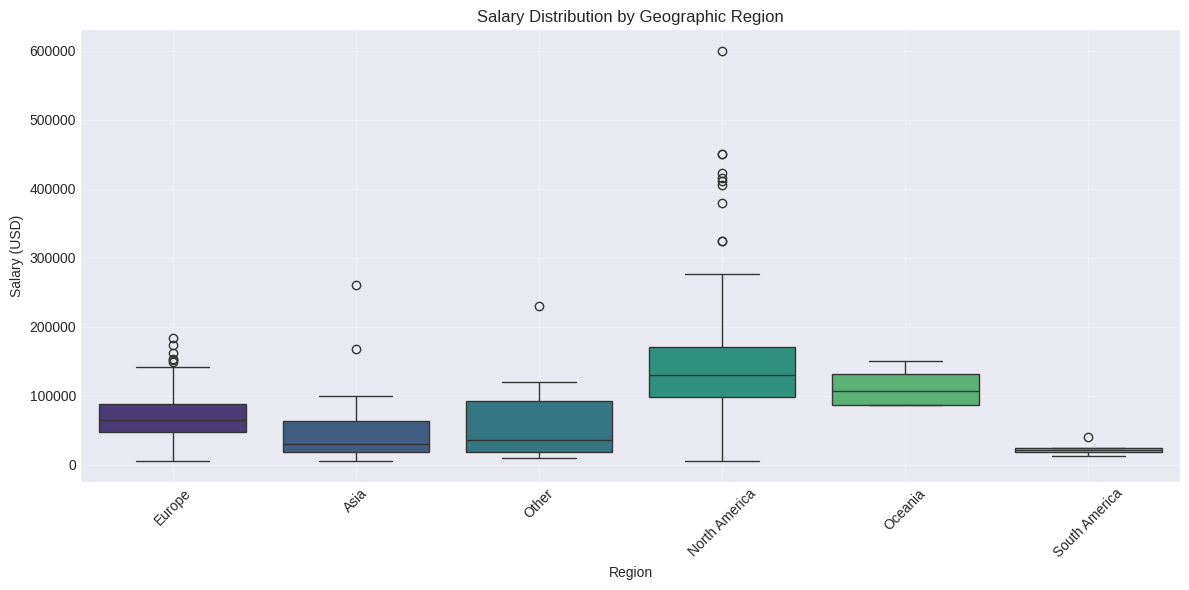


Mean Salary by Region:


,mean,median,count
region,,,
North America,140178.433908,130000.0,348
Oceania,112282.000000,106212.5,4
Europe,70329.510638,65013.0,141
Other,56861.481481,35735.0,27
Asia,45495.972973,29751.0,37
South America,23538.000000,21844.0,5



✓ Saved: salary_by_region.png


In [ ]:
# 3.5 Salary by Region
print("\n3.5 SALARY BY REGION")
print("-"*80)

fig, ax = plt.subplots(figsize=(12, 6))

region_stats = ds_clean.groupby('region')['salary_in_usd'].agg(['mean', 'count']).sort_values('mean', ascending=False)
regions_to_plot = region_stats[region_stats['count'] >= 3].index  # Only regions with 3+ records

sns.boxplot(data=ds_clean[ds_clean['region'].isin(regions_to_plot)],
            x='region', y='salary_in_usd', palette='viridis', ax=ax)
ax.set_xlabel('Region')
ax.set_ylabel('Salary (USD)')
ax.set_title('Salary Distribution by Geographic Region')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('salary_by_region.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMean Salary by Region:")
display(ds_clean.groupby('region')['salary_in_usd'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))

print("\n✓ Saved: salary_by_region.png")


3.6 CORRELATION ANALYSIS
--------------------------------------------------------------------------------


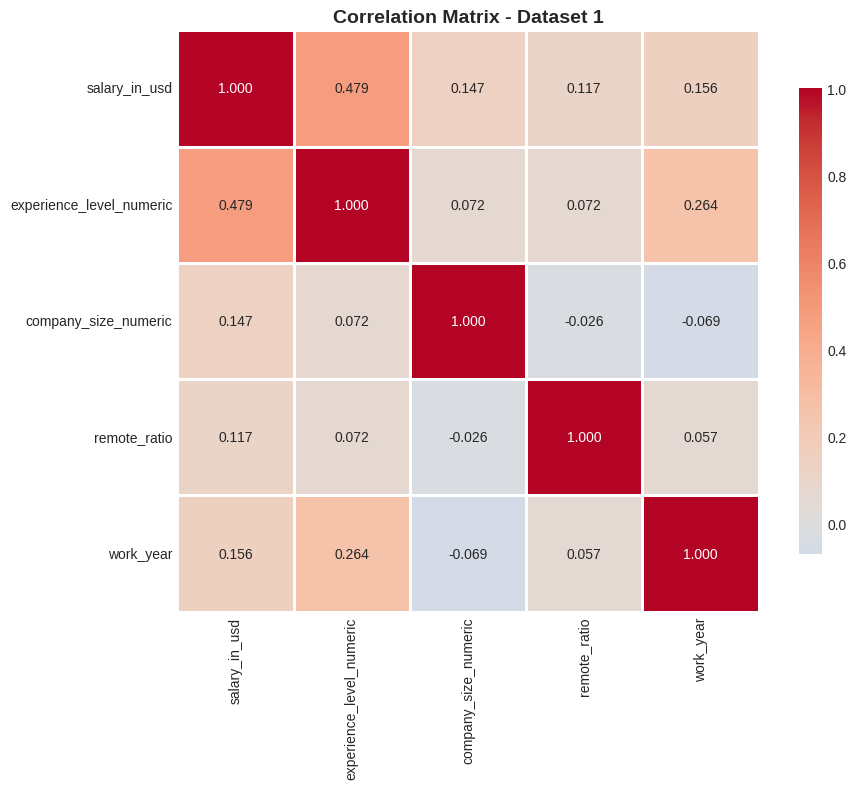


Correlation with Salary:


,salary_in_usd
salary_in_usd,1.000000
experience_level_numeric,0.479071
work_year,0.156223
company_size_numeric,0.147024
remote_ratio,0.117098



✓ Saved: correlation_heatmap.png


In [ ]:
# 3.6 Correlation Analysis
print("\n3.6 CORRELATION ANALYSIS")
print("-"*80)

# Select numeric columns
numeric_cols = ['salary_in_usd', 'experience_level_numeric', 'company_size_numeric', 'remote_ratio', 'work_year']
corr_data = ds_clean[numeric_cols]

# Calculate correlation matrix
correlation_matrix = corr_data.corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Dataset 1', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation with Salary:")
display(correlation_matrix['salary_in_usd'].sort_values(ascending=False))

print("\n✓ Saved: correlation_heatmap.png")


3.7 SALARY TRENDS OVER TIME (2020-2022)
--------------------------------------------------------------------------------


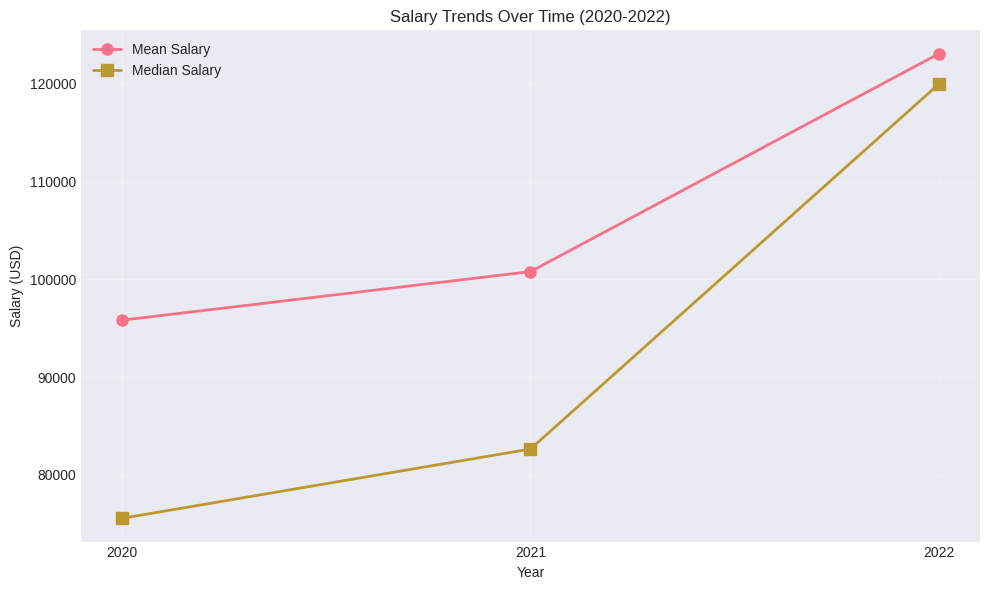


Yearly Statistics:


,mean,median
work_year,,
2020,95813.000000,75544.0
2021,100786.226415,82636.0
2022,123089.097122,120000.0



✓ Saved: salary_trends.png

✓ STEP 3 COMPLETE!


In [ ]:
# 3.7 Salary Trends Over Time
print("\n3.7 SALARY TRENDS OVER TIME (2020-2022)")
print("-"*80)

fig, ax = plt.subplots(figsize=(10, 6))

yearly_stats = ds_clean.groupby('work_year')['salary_in_usd'].agg(['mean', 'median'])

ax.plot(yearly_stats.index, yearly_stats['mean'], marker='o', linewidth=2,
        markersize=8, label='Mean Salary')
ax.plot(yearly_stats.index, yearly_stats['median'], marker='s', linewidth=2,
        markersize=8, label='Median Salary')
ax.set_xlabel('Year')
ax.set_ylabel('Salary (USD)')
ax.set_title('Salary Trends Over Time (2020-2022)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks([2020, 2021, 2022])

plt.tight_layout()
plt.savefig('salary_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nYearly Statistics:")
display(yearly_stats)

print("\n✓ Saved: salary_trends.png")
print("\n✓ STEP 3 COMPLETE!")

In [ ]:
print("="*80)
print("STEP 4: STATISTICAL ANALYSIS")
print("="*80)

STEP 4: STATISTICAL ANALYSIS


In [ ]:
# 4.1 Independent T-Test: Senior vs Mid-level Salaries
print("\n4.1 T-TEST: Senior vs Mid-level Salaries")
print("-"*80)

senior_salaries = ds_clean[ds_clean['experience_level'] == 'SE']['salary_in_usd']
mid_salaries = ds_clean[ds_clean['experience_level'] == 'MI']['salary_in_usd']

# Perform t-test
t_stat, p_value = stats.ttest_ind(senior_salaries, mid_salaries)

print(f"H0: Senior and Mid-level salaries are equal")
print(f"H1: Senior salaries are different from Mid-level\n")

print(f"Senior Mean: ${senior_salaries.mean():,.2f}")
print(f"Mid-level Mean: ${mid_salaries.mean():,.2f}")
print(f"Difference: ${senior_salaries.mean() - mid_salaries.mean():,.2f}")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\n✓ REJECT H0: There IS a significant difference (p < 0.05)")
else:
    print("\n✗ FAIL TO REJECT H0: No significant difference (p >= 0.05)")


4.1 T-TEST: Senior vs Mid-level Salaries
--------------------------------------------------------------------------------
H0: Senior and Mid-level salaries are equal
H1: Senior salaries are different from Mid-level

Senior Mean: $138,374.88
Mid-level Mean: $88,612.06
Difference: $49,762.82

T-statistic: 8.5037
P-value: 0.000000

✓ REJECT H0: There IS a significant difference (p < 0.05)


In [ ]:
# 4.2 ANOVA: Salary across all experience levels
print("\n4.2 ANOVA: Salary Across All Experience Levels")
print("-"*80)

# Prepare groups
entry_salaries = ds_clean[ds_clean['experience_level'] == 'EN']['salary_in_usd']
exec_salaries = ds_clean[ds_clean['experience_level'] == 'EX']['salary_in_usd']

# Perform ANOVA
f_stat, p_value_anova = stats.f_oneway(entry_salaries, mid_salaries, senior_salaries, exec_salaries)

print(f"H0: All experience levels have equal mean salaries")
print(f"H1: At least one group has different mean salary\n")

print(f"Entry Mean: ${entry_salaries.mean():,.2f}")
print(f"Mid Mean: ${mid_salaries.mean():,.2f}")
print(f"Senior Mean: ${senior_salaries.mean():,.2f}")
print(f"Executive Mean: ${exec_salaries.mean():,.2f}")

print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.6f}")

if p_value_anova < 0.05:
    print("\n✓ REJECT H0: At least one group differs significantly (p < 0.05)")
else:
    print("\n✗ FAIL TO REJECT H0: No significant differences (p >= 0.05)")


4.2 ANOVA: Salary Across All Experience Levels
--------------------------------------------------------------------------------
H0: All experience levels have equal mean salaries
H1: At least one group has different mean salary

Entry Mean: $62,305.89
Mid Mean: $88,612.06
Senior Mean: $138,374.88
Executive Mean: $199,392.04

F-statistic: 58.2799
P-value: 0.000000

✓ REJECT H0: At least one group differs significantly (p < 0.05)


In [ ]:
# 4.3 Chi-Square Test: Company Size vs Experience Level
print("\n4.3 CHI-SQUARE TEST: Company Size vs Experience Level")
print("-"*80)

# Create contingency table
contingency_table = pd.crosstab(ds_clean['company_size'], ds_clean['experience_level'])
print("\nContingency Table:")
display(contingency_table)

# Perform chi-square test
chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nH0: Company size and experience level are independent")
print(f"H1: Company size and experience level are associated\n")

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value_chi:.6f}")
print(f"Degrees of freedom: {dof}")

if p_value_chi < 0.05:
    print("\n✓ REJECT H0: There IS an association (p < 0.05)")
else:
    print("\n✗ FAIL TO REJECT H0: No significant association (p >= 0.05)")


4.3 CHI-SQUARE TEST: Company Size vs Experience Level
--------------------------------------------------------------------------------

Contingency Table:


experience_level,EN,EX,MI,SE
company_size,,,,
L,29,11,84,69
M,29,12,95,152
S,29,3,27,22



H0: Company size and experience level are independent
H1: Company size and experience level are associated

Chi-square statistic: 45.0342
P-value: 0.000000
Degrees of freedom: 6

✓ REJECT H0: There IS an association (p < 0.05)


In [ ]:
# 4.4 Correlation Tests
print("\n4.4 CORRELATION TESTS")
print("-"*80)

# Pearson correlation: Salary vs Experience Level (numeric)
pearson_corr, pearson_p = stats.pearsonr(ds_clean['salary_in_usd'],
                                          ds_clean['experience_level_numeric'])

print(f"Pearson Correlation (Salary vs Experience Level):")
print(f"  Correlation coefficient: {pearson_corr:.4f}")
print(f"  P-value: {pearson_p:.6f}")

if pearson_p < 0.05:
    print(f"  ✓ Significant correlation (p < 0.05)")
else:
    print(f"  ✗ No significant correlation (p >= 0.05)")

# Spearman correlation: Salary vs Remote Ratio
spearman_corr, spearman_p = stats.spearmanr(ds_clean['salary_in_usd'],
                                             ds_clean['remote_ratio'])

print(f"\nSpearman Correlation (Salary vs Remote Ratio):")
print(f"  Correlation coefficient: {spearman_corr:.4f}")
print(f"  P-value: {spearman_p:.6f}")

if spearman_p < 0.05:
    print(f"  ✓ Significant correlation (p < 0.05)")
else:
    print(f"  ✗ No significant correlation (p >= 0.05)")


4.4 CORRELATION TESTS
--------------------------------------------------------------------------------
Pearson Correlation (Salary vs Experience Level):
  Correlation coefficient: 0.4791
  P-value: 0.000000
  ✓ Significant correlation (p < 0.05)

Spearman Correlation (Salary vs Remote Ratio):
  Correlation coefficient: 0.1592
  P-value: 0.000151
  ✓ Significant correlation (p < 0.05)


In [ ]:
# 4.5 Summary of Statistical Tests
print("\n" + "="*80)
print("STATISTICAL TESTS SUMMARY")
print("="*80)

results_summary = pd.DataFrame({
    'Test': [
        'T-Test (Senior vs Mid)',
        'ANOVA (All Experience Levels)',
        'Chi-Square (Size vs Experience)',
        'Pearson (Salary vs Experience)',
        'Spearman (Salary vs Remote)'
    ],
    'Test Statistic': [
        f"{t_stat:.4f}",
        f"{f_stat:.4f}",
        f"{chi2:.4f}",
        f"{pearson_corr:.4f}",
        f"{spearman_corr:.4f}"
    ],
    'P-Value': [
        f"{p_value:.6f}",
        f"{p_value_anova:.6f}",
        f"{p_value_chi:.6f}",
        f"{pearson_p:.6f}",
        f"{spearman_p:.6f}"
    ],
    'Result (α=0.05)': [
        'Significant' if p_value < 0.05 else 'Not Significant',
        'Significant' if p_value_anova < 0.05 else 'Not Significant',
        'Significant' if p_value_chi < 0.05 else 'Not Significant',
        'Significant' if pearson_p < 0.05 else 'Not Significant',
        'Significant' if spearman_p < 0.05 else 'Not Significant'
    ]
})

display(results_summary)

print("\n✓ STEP 4 COMPLETE!")


STATISTICAL TESTS SUMMARY


,Test,Test Statistic,P-Value,Result (α=0.05)
0,T-Test (Senior vs Mid),8.5037,0.000000,Significant
1,ANOVA (All Experience Levels),58.2799,0.000000,Significant
2,Chi-Square (Size vs Experience),45.0342,0.000000,Significant
3,Pearson (Salary vs Experience),0.4791,0.000000,Significant
4,Spearman (Salary vs Remote),0.1592,0.000151,Significant



✓ STEP 4 COMPLETE!


In [ ]:
print("="*80)
print("STEP 5: FEATURE ENGINEERING")
print("="*80)

# Create a copy for modeling
ds_model = ds_clean.copy()

print(f"\nStarting with {len(ds_model)} records and {len(ds_model.columns)} columns")

STEP 5: FEATURE ENGINEERING

Starting with 562 records and 16 columns


In [ ]:
# 5.1 Create Additional Features
print("\n5.1 CREATING ADDITIONAL FEATURES")
print("-"*80)

# Years since first year in dataset
ds_model['years_in_market'] = ds_model['work_year'] - 2020
print("✓ Created 'years_in_market'")

# US-based flag
ds_model['is_us_based'] = (ds_model['company_location'] == 'US').astype(int)
print("✓ Created 'is_us_based'")

# Fully remote flag
ds_model['is_fully_remote'] = (ds_model['remote_ratio'] == 100).astype(int)
print("✓ Created 'is_fully_remote'")

# High-demand role flag (Data Scientist, ML Engineer, Data Engineer)
high_demand_roles = ['Data Scientist', 'Machine Learning Engineer', 'Data Engineer']
ds_model['is_high_demand_role'] = ds_model['job_title'].isin(high_demand_roles).astype(int)
print("✓ Created 'is_high_demand_role'")

# Large company flag
ds_model['is_large_company'] = (ds_model['company_size'] == 'L').astype(int)
print("✓ Created 'is_large_company'")

print(f"\nCurrent columns: {len(ds_model.columns)}")


5.1 CREATING ADDITIONAL FEATURES
--------------------------------------------------------------------------------
✓ Created 'years_in_market'
✓ Created 'is_us_based'
✓ Created 'is_fully_remote'
✓ Created 'is_high_demand_role'
✓ Created 'is_large_company'

Current columns: 21


In [ ]:
# 5.2 One-Hot Encoding for Categorical Variables
print("\n5.2 ONE-HOT ENCODING")
print("-"*80)

# Encode experience level
exp_dummies = pd.get_dummies(ds_model['experience_level'], prefix='exp')
ds_model = pd.concat([ds_model, exp_dummies], axis=1)
print(f"✓ Encoded 'experience_level': {list(exp_dummies.columns)}")

# Encode company size
size_dummies = pd.get_dummies(ds_model['company_size'], prefix='size')
ds_model = pd.concat([ds_model, size_dummies], axis=1)
print(f"✓ Encoded 'company_size': {list(size_dummies.columns)}")

# Encode employment type
emp_dummies = pd.get_dummies(ds_model['employment_type'], prefix='emp')
ds_model = pd.concat([ds_model, emp_dummies], axis=1)
print(f"✓ Encoded 'employment_type': {list(emp_dummies.columns)}")

# Encode region
region_dummies = pd.get_dummies(ds_model['region'], prefix='region')
ds_model = pd.concat([ds_model, region_dummies], axis=1)
print(f"✓ Encoded 'region': {list(region_dummies.columns)}")

print(f"\nTotal columns after encoding: {len(ds_model.columns)}")


5.2 ONE-HOT ENCODING
--------------------------------------------------------------------------------
✓ Encoded 'experience_level': ['exp_EN', 'exp_EX', 'exp_MI', 'exp_SE']
✓ Encoded 'company_size': ['size_L', 'size_M', 'size_S']
✓ Encoded 'employment_type': ['emp_CT', 'emp_FL', 'emp_FT', 'emp_PT']
✓ Encoded 'region': ['region_Asia', 'region_Europe', 'region_North America', 'region_Oceania', 'region_Other', 'region_South America']

Total columns after encoding: 38


In [ ]:
# 5.3 Select Features for Modeling
print("\n5.3 SELECTING FEATURES FOR MODELING")
print("-"*80)

# Define feature columns
feature_cols = [
    # Numeric features
    'experience_level_numeric', 'company_size_numeric', 'remote_ratio',
    'work_year', 'years_in_market',

    # Binary features
    'is_us_based', 'is_fully_remote', 'is_high_demand_role', 'is_large_company',

    # One-hot encoded (excluding one category from each to avoid multicollinearity)
    'exp_MI', 'exp_SE', 'exp_EX',  # EN is reference
    'size_M', 'size_L',  # S is reference
    'region_Asia', 'region_Europe', 'region_North America',  # Other is reference
]

# Target variable
target_col = 'salary_in_usd'

# Create feature matrix and target vector
X = ds_model[feature_cols]
y = ds_model[target_col]

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nSelected features ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

print("\n✓ Features selected and ready for modeling")


5.3 SELECTING FEATURES FOR MODELING
--------------------------------------------------------------------------------

Feature matrix shape: (562, 17)
Target vector shape: (562,)

Selected features (17):
  1. experience_level_numeric
  2. company_size_numeric
  3. remote_ratio
  4. work_year
  5. years_in_market
  6. is_us_based
  7. is_fully_remote
  8. is_high_demand_role
  9. is_large_company
  10. exp_MI
  11. exp_SE
  12. exp_EX
  13. size_M
  14. size_L
  15. region_Asia
  16. region_Europe
  17. region_North America

✓ Features selected and ready for modeling


In [ ]:
# 5.4 Train-Test Split
print("\n5.4 TRAIN-TEST SPLIT")
print("-"*80)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Split ratio: 80-20")
print(f"\nTraining salary range: ${y_train.min():,.0f} - ${y_train.max():,.0f}")
print(f"Test salary range: ${y_test.min():,.0f} - ${y_test.max():,.0f}")

print("\n✓ Data split complete")


5.4 TRAIN-TEST SPLIT
--------------------------------------------------------------------------------
Training set: 449 samples
Test set: 113 samples
Split ratio: 80-20

Training salary range: $5,679 - $450,000
Test salary range: $5,409 - $600,000

✓ Data split complete


In [ ]:
# 5.5 Feature Scaling
print("\n5.5 FEATURE SCALING")
print("-"*80)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print(f"  Mean after scaling: {X_train_scaled.mean():.6f}")
print(f"  Std after scaling: {X_train_scaled.std():.6f}")

print("\n✓ STEP 5 COMPLETE!")
print("\nData is ready for machine learning models!")


5.5 FEATURE SCALING
--------------------------------------------------------------------------------
✓ Features scaled using StandardScaler
  Mean after scaling: -0.000000
  Std after scaling: 1.000000

✓ STEP 5 COMPLETE!

Data is ready for machine learning models!


In [ ]:
print("="*80)
print("STEP 6: MACHINE LEARNING MODELS")
print("="*80)

# Dictionary to store results
model_results = {}

STEP 6: MACHINE LEARNING MODELS


In [ ]:
# 6.1 Model 1: Linear Regression (Baseline)
print("\n6.1 LINEAR REGRESSION (Baseline Model)")
print("-"*80)

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

print(f"Training R² Score: {train_r2_lr:.4f}")
print(f"Test R² Score: {test_r2_lr:.4f}")
print(f"Test RMSE: ${test_rmse_lr:,.2f}")
print(f"Test MAE: ${test_mae_lr:,.2f}")

# Store results
model_results['Linear Regression'] = {
    'Train R²': train_r2_lr,
    'Test R²': test_r2_lr,
    'RMSE': test_rmse_lr,
    'MAE': test_mae_lr
}

print("\n✓ Linear Regression complete")


6.1 LINEAR REGRESSION (Baseline Model)
--------------------------------------------------------------------------------
Training R² Score: 0.4315
Test R² Score: 0.3846
Test RMSE: $67,383.65
Test MAE: $40,294.34

✓ Linear Regression complete


In [ ]:
# 6.2 Model 2: Ridge Regression
print("\n6.2 RIDGE REGRESSION (with Regularization)")
print("-"*80)

# Train model with default alpha
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

# Evaluation
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

print(f"Training R² Score: {train_r2_ridge:.4f}")
print(f"Test R² Score: {test_r2_ridge:.4f}")
print(f"Test RMSE: ${test_rmse_ridge:,.2f}")
print(f"Test MAE: ${test_mae_ridge:,.2f}")

# Store results
model_results['Ridge Regression'] = {
    'Train R²': train_r2_ridge,
    'Test R²': test_r2_ridge,
    'RMSE': test_rmse_ridge,
    'MAE': test_mae_ridge
}

print("\n✓ Ridge Regression complete")


6.2 RIDGE REGRESSION (with Regularization)
--------------------------------------------------------------------------------
Training R² Score: 0.4315
Test R² Score: 0.3845
Test RMSE: $67,387.92
Test MAE: $40,278.23

✓ Ridge Regression complete


In [ ]:
# 6.3 Model 3: Random Forest Regressor
print("\n6.3 RANDOM FOREST REGRESSOR")
print("-"*80)

# Train model (using unscaled data - tree-based models don't need scaling)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10,
                                  min_samples_split=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluation
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)

print(f"Training R² Score: {train_r2_rf:.4f}")
print(f"Test R² Score: {test_r2_rf:.4f}")
print(f"Test RMSE: ${test_rmse_rf:,.2f}")
print(f"Test MAE: ${test_mae_rf:,.2f}")

# Store results
model_results['Random Forest'] = {
    'Train R²': train_r2_rf,
    'Test R²': test_r2_rf,
    'RMSE': test_rmse_rf,
    'MAE': test_mae_rf
}

print("\n✓ Random Forest complete")


6.3 RANDOM FOREST REGRESSOR
--------------------------------------------------------------------------------
Training R² Score: 0.6303
Test R² Score: 0.4010
Test RMSE: $66,480.15
Test MAE: $38,835.17

✓ Random Forest complete



6.4 FEATURE IMPORTANCE (Random Forest)
--------------------------------------------------------------------------------

Top 10 Most Important Features:


,Feature,Importance
5,is_us_based,0.336445
0,experience_level_numeric,0.164830
16,region_North America,0.074834
7,is_high_demand_role,0.064074
1,company_size_numeric,0.058538
2,remote_ratio,0.051667
3,work_year,0.046956
4,years_in_market,0.042259
11,exp_EX,0.030908
6,is_fully_remote,0.024334


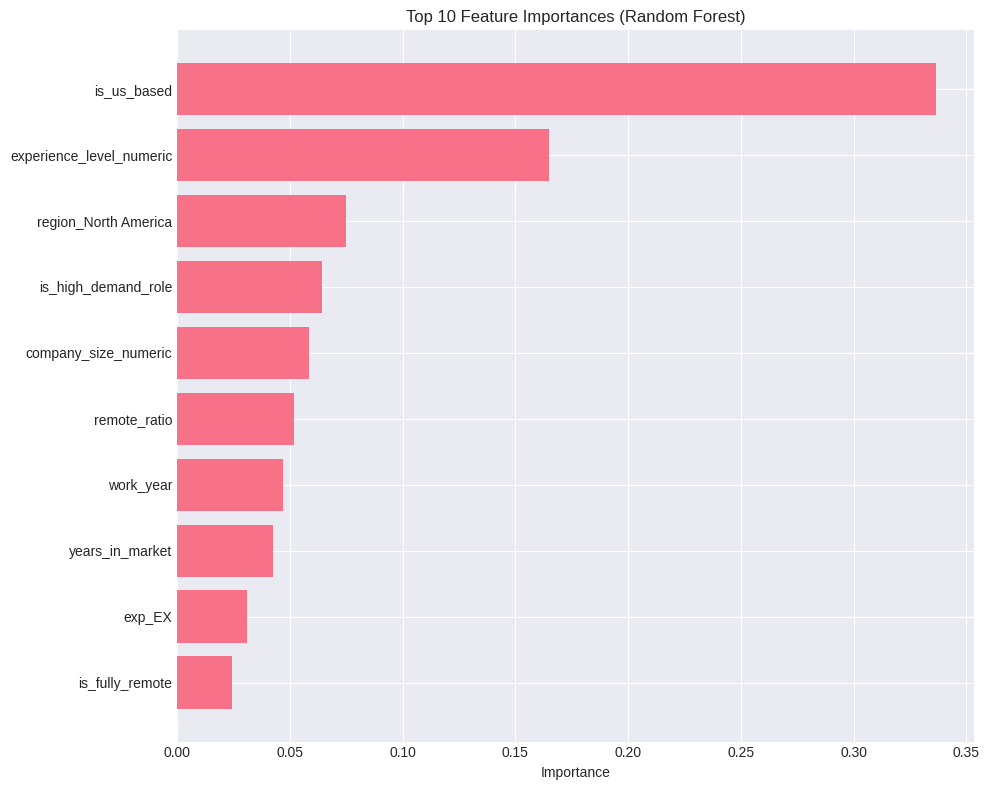


✓ Saved: feature_importance.png


In [ ]:
# 6.4 Feature Importance from Random Forest
print("\n6.4 FEATURE IMPORTANCE (Random Forest)")
print("-"*80)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
display(feature_importance.head(10))

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(10)
ax.barh(range(len(top_features)), top_features['Importance'])
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Importance')
ax.set_title('Top 10 Feature Importances (Random Forest)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: feature_importance.png")

In [ ]:
# 6.5 Model 4: XGBoost Regressor
print("\n6.5 XGBOOST REGRESSOR")
print("-"*80)

# Train model
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                             random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Evaluation
train_r2_xgb = r2_score(y_train, y_train_pred_xgb)
test_r2_xgb = r2_score(y_test, y_test_pred_xgb)
test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
test_mae_xgb = mean_absolute_error(y_test, y_test_pred_xgb)

print(f"Training R² Score: {train_r2_xgb:.4f}")
print(f"Test R² Score: {test_r2_xgb:.4f}")
print(f"Test RMSE: ${test_rmse_xgb:,.2f}")
print(f"Test MAE: ${test_mae_xgb:,.2f}")

# Store results
model_results['XGBoost'] = {
    'Train R²': train_r2_xgb,
    'Test R²': test_r2_xgb,
    'RMSE': test_rmse_xgb,
    'MAE': test_mae_xgb
}

print("\n✓ XGBoost complete")


6.5 XGBOOST REGRESSOR
--------------------------------------------------------------------------------
Training R² Score: 0.6951
Test R² Score: 0.3625
Test RMSE: $68,583.29
Test MAE: $41,450.54

✓ XGBoost complete


In [ ]:
# 6.6 Model Comparison
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)

comparison_df = pd.DataFrame(model_results).T
comparison_df = comparison_df.round(4)

print("\n")
display(comparison_df)

# Find best model
best_model = comparison_df['Test R²'].idxmax()
print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   Test R² Score: {comparison_df.loc[best_model, 'Test R²']:.4f}")
print(f"   Test RMSE: ${comparison_df.loc[best_model, 'RMSE']:,.2f}")


MODEL PERFORMANCE COMPARISON




,Train R²,Test R²,RMSE,MAE
Linear Regression,0.4315,0.3846,67383.6526,40294.3435
Ridge Regression,0.4315,0.3845,67387.9177,40278.2274
Random Forest,0.6303,0.4010,66480.1453,38835.1694
XGBoost,0.6951,0.3625,68583.2903,41450.5391



🏆 BEST MODEL: Random Forest
   Test R² Score: 0.4010
   Test RMSE: $66,480.15



6.7 ACTUAL VS PREDICTED VISUALIZATION
--------------------------------------------------------------------------------


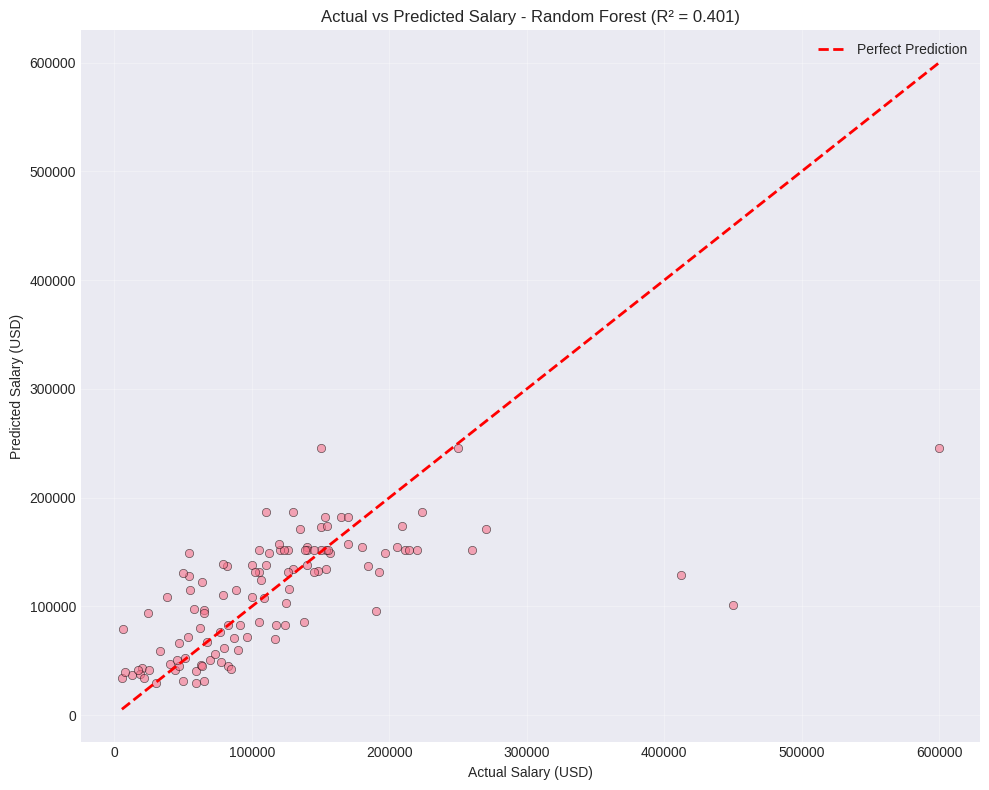


✓ Saved: actual_vs_predicted.png

✓ STEP 6 COMPLETE!


In [ ]:
# 6.7 Actual vs Predicted (Best Model)
print("\n6.7 ACTUAL VS PREDICTED VISUALIZATION")
print("-"*80)

# Use Random Forest predictions (usually best)
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(y_test, y_test_pred_rf, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Salary (USD)')
ax.set_ylabel('Predicted Salary (USD)')
ax.set_title(f'Actual vs Predicted Salary - {best_model} (R² = {test_r2_rf:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: actual_vs_predicted.png")
print("\n✓ STEP 6 COMPLETE!")

In [ ]:
print("="*80)
print("STEP 7: VALIDATION WITH STACK OVERFLOW DATA")
print("="*80)

STEP 7: VALIDATION WITH STACK OVERFLOW DATA



7.1 SALARY DISTRIBUTION COMPARISON
--------------------------------------------------------------------------------


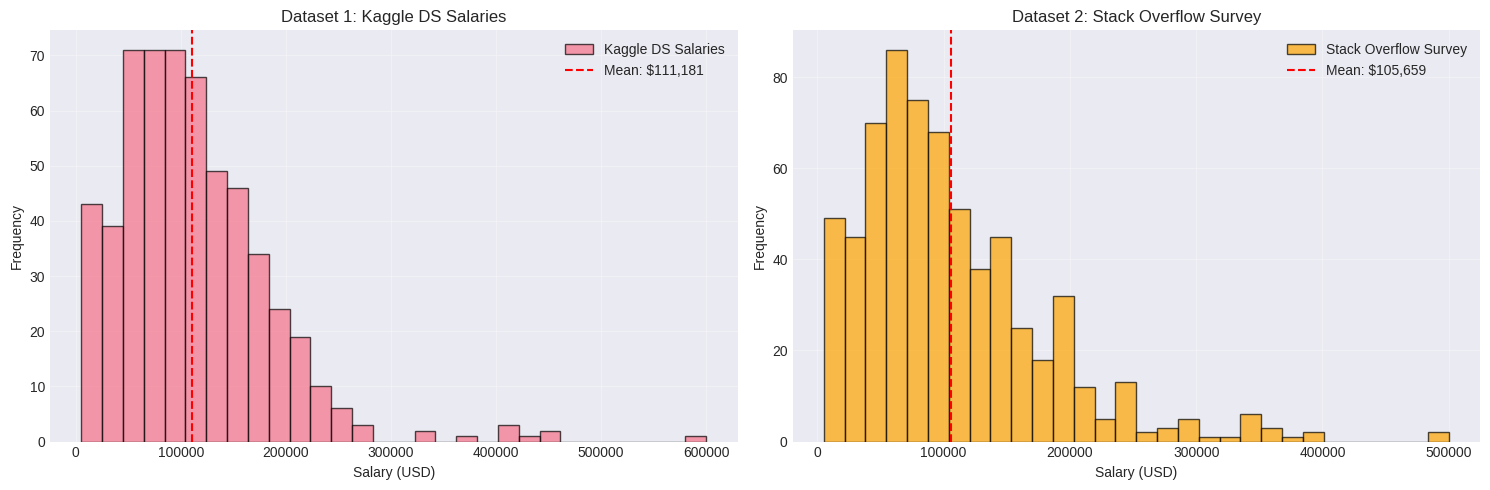


✓ Saved: validation_salary_comparison.png


In [ ]:
# 7.1 Compare Salary Distributions
print("\n7.1 SALARY DISTRIBUTION COMPARISON")
print("-"*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Dataset 1
axes[0].hist(ds_clean['salary_in_usd'], bins=30, alpha=0.7, edgecolor='black', label='Kaggle DS Salaries')
axes[0].axvline(ds_clean['salary_in_usd'].mean(), color='red', linestyle='--',
                label=f"Mean: ${ds_clean['salary_in_usd'].mean():,.0f}")
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Dataset 1: Kaggle DS Salaries')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dataset 2
axes[1].hist(so_clean['ConvertedCompYearly'], bins=30, alpha=0.7, edgecolor='black',
             color='orange', label='Stack Overflow Survey')
axes[1].axvline(so_clean['ConvertedCompYearly'].mean(), color='red', linestyle='--',
                label=f"Mean: ${so_clean['ConvertedCompYearly'].mean():,.0f}")
axes[1].set_xlabel('Salary (USD)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Dataset 2: Stack Overflow Survey')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('validation_salary_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: validation_salary_comparison.png")


7.2 EDUCATION IMPACT ON SALARY (Stack Overflow Data)
--------------------------------------------------------------------------------

Salary by Education Level:


,mean,median,count
EdLevel,,,
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",126119.240741,110851.5,108
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",107305.855072,88492.0,276
Primary/elementary school,105353.000000,105353.0,1
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",99713.917476,85278.5,206
"Associate degree (A.A., A.S., etc.)",91454.500000,55935.0,8
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",85340.312500,84876.5,16
Some college/university study without earning a degree,80239.815789,64404.0,38
Other (please specify):,56442.500000,56442.5,2


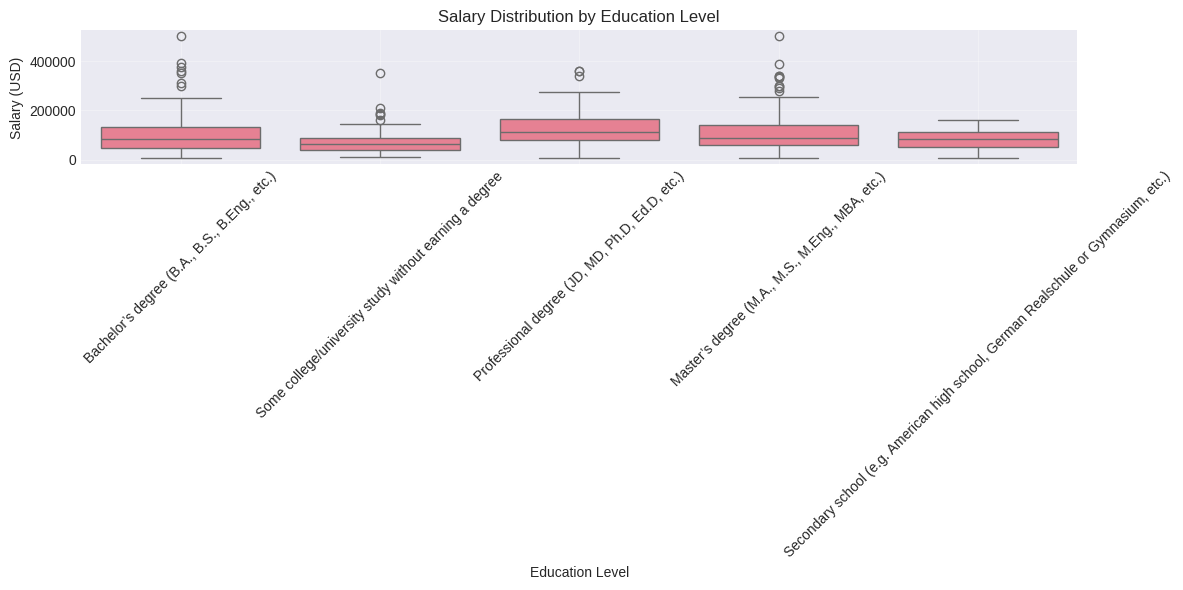


✓ Saved: salary_by_education.png


In [ ]:
# 7.2 Education Impact Analysis (Stack Overflow Only)
print("\n7.2 EDUCATION IMPACT ON SALARY (Stack Overflow Data)")
print("-"*80)

if 'EdLevel' in so_clean.columns:
    ed_stats = so_clean.groupby('EdLevel')['ConvertedCompYearly'].agg(['mean', 'median', 'count'])
    ed_stats = ed_stats.sort_values('mean', ascending=False)

    print("\nSalary by Education Level:")
    display(ed_stats)

    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))
    ed_levels = ed_stats[ed_stats['count'] >= 10].index  # Only levels with 10+ records

    so_filtered = so_clean[so_clean['EdLevel'].isin(ed_levels)]
    sns.boxplot(data=so_filtered, x='EdLevel', y='ConvertedCompYearly', ax=ax)
    ax.set_xlabel('Education Level')
    ax.set_ylabel('Salary (USD)')
    ax.set_title('Salary Distribution by Education Level')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('salary_by_education.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Saved: salary_by_education.png")
else:
    print("EdLevel column not found in Stack Overflow data")


7.3 AGE IMPACT ON SALARY (Stack Overflow Data)
--------------------------------------------------------------------------------

Salary by Age Group:


,mean,median,count
Age,,,
Prefer not to say,162523.000000,162523.0,1
65 years or older,140757.000000,142500.0,8
45-54 years old,134253.035398,120000.0,113
55-64 years old,113458.463415,105000.0,41
35-44 years old,111309.078947,94486.0,190
25-34 years old,96036.038023,80050.0,263
18-24 years old,47770.571429,42365.5,42


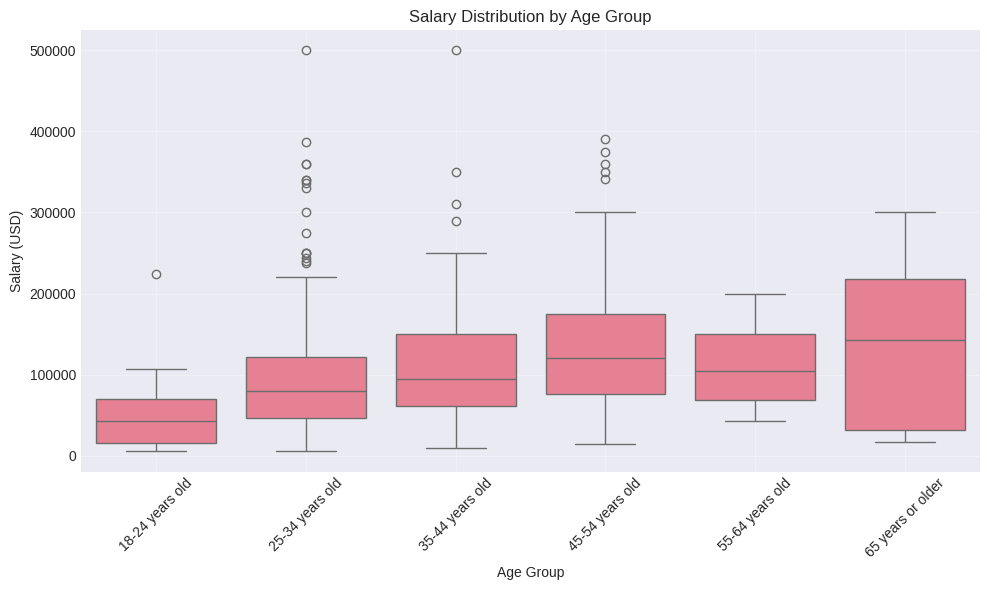


✓ Saved: salary_by_age.png


In [ ]:
# 7.3 Age Impact Analysis (Stack Overflow Only)
print("\n7.3 AGE IMPACT ON SALARY (Stack Overflow Data)")
print("-"*80)

if 'Age' in so_clean.columns:
    age_stats = so_clean.groupby('Age')['ConvertedCompYearly'].agg(['mean', 'median', 'count'])
    age_stats = age_stats.sort_values('mean', ascending=False)

    print("\nSalary by Age Group:")
    display(age_stats)

    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    age_order = ['18-24 years old', '25-34 years old', '35-44 years old',
                 '45-54 years old', '55-64 years old', '65 years or older']
    age_order = [a for a in age_order if a in so_clean['Age'].values]

    sns.boxplot(data=so_clean, x='Age', y='ConvertedCompYearly', order=age_order, ax=ax)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Salary (USD)')
    ax.set_title('Salary Distribution by Age Group')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('salary_by_age.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Saved: salary_by_age.png")
else:
    print("Age column not found in Stack Overflow data")

In [ ]:
# 7.4 Cross-Dataset Insights Summary
print("\n" + "="*80)
print("CROSS-DATASET VALIDATION SUMMARY")
print("="*80)

summary_insights = pd.DataFrame({
    'Metric': [
        'Sample Size',
        'Mean Salary',
        'Median Salary',
        'Std Deviation',
        'Salary Range',
        'Top Factor'
    ],
    'Dataset 1 (Kaggle)': [
        f"{len(ds_clean)} records",
        f"${ds_clean['salary_in_usd'].mean():,.0f}",
        f"${ds_clean['salary_in_usd'].median():,.0f}",
        f"${ds_clean['salary_in_usd'].std():,.0f}",
        f"${ds_clean['salary_in_usd'].min():,.0f} - ${ds_clean['salary_in_usd'].max():,.0f}",
        "Experience Level"
    ],
    'Dataset 2 (Stack Overflow)': [
        f"{len(so_clean)} records",
        f"${so_clean['ConvertedCompYearly'].mean():,.0f}",
        f"${so_clean['ConvertedCompYearly'].median():,.0f}",
        f"${so_clean['ConvertedCompYearly'].std():,.0f}",
        f"${so_clean['ConvertedCompYearly'].min():,.0f} - ${so_clean['ConvertedCompYearly'].max():,.0f}",
        "Education & Age"
    ]
})

display(summary_insights)

print("\n✓ STEP 7 COMPLETE!")
print("\n" + "="*80)
print("ALL ANALYSIS STEPS COMPLETE!")
print("="*80)


CROSS-DATASET VALIDATION SUMMARY


,Metric,Dataset 1 (Kaggle),Dataset 2 (Stack Overflow)
0,Sample Size,562 records,658 records
1,Mean Salary,"$111,181","$105,659"
2,Median Salary,"$100,000","$88,332"
3,Std Deviation,"$72,048","$74,106"
4,Salary Range,"$5,409 - $600,000","$5,097 - $500,000"
5,Top Factor,Experience Level,Education & Age



✓ STEP 7 COMPLETE!

ALL ANALYSIS STEPS COMPLETE!


In [ ]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE - SUMMARY")
print("="*80)

print("\n✓ Steps Completed:")
print("  1. Data Understanding")
print("  2. Data Cleaning")
print("  3. Exploratory Data Analysis")
print("  4. Statistical Analysis")
print("  5. Feature Engineering")
print("  6. Machine Learning Models")
print("  7. Validation with Stack Overflow Data")

print("\n📁 Files Created:")
print("  • salary_distribution.png")
print("  • salary_by_experience.png")
print("  • salary_by_company_size.png")
print("  • salary_by_remote.png")
print("  • salary_by_region.png")
print("  • correlation_heatmap.png")
print("  • salary_trends.png")
print("  • feature_importance.png")
print("  • actual_vs_predicted.png")
print("  • validation_salary_comparison.png")
print("  • salary_by_education.png")
print("  • salary_by_age.png")

print("\n🏆 Best Model Performance:")
print(f"  Model: {best_model}")
print(f"  Test R² Score: {comparison_df.loc[best_model, 'Test R²']:.4f}")
print(f"  Test RMSE: ${comparison_df.loc[best_model, 'RMSE']:,.2f}")
print(f"  Test MAE: ${comparison_df.loc[best_model, 'MAE']:,.2f}")

print("\n📝 Next Steps:")
print("  1. Download all PNG files from Colab")
print("  2. Create Excel analysis (pivot tables, charts)")
print("  3. Build Power BI dashboard")
print("  4. Write final report (12-15 pages)")
print("  5. Set up GitHub repository")

print("\n" + "="*80)
print("READY FOR EXCEL & POWER BI ANALYSIS!")
print("="*80)


ANALYSIS COMPLETE - SUMMARY

✓ Steps Completed:
  1. Data Understanding
  2. Data Cleaning
  3. Exploratory Data Analysis
  4. Statistical Analysis
  5. Feature Engineering
  6. Machine Learning Models
  7. Validation with Stack Overflow Data

📁 Files Created:
  • salary_distribution.png
  • salary_by_experience.png
  • salary_by_company_size.png
  • salary_by_remote.png
  • salary_by_region.png
  • correlation_heatmap.png
  • salary_trends.png
  • feature_importance.png
  • actual_vs_predicted.png
  • validation_salary_comparison.png
  • salary_by_education.png
  • salary_by_age.png

🏆 Best Model Performance:
  Model: Random Forest
  Test R² Score: 0.4010
  Test RMSE: $66,480.15
  Test MAE: $38,835.17

📝 Next Steps:
  1. Download all PNG files from Colab
  2. Create Excel analysis (pivot tables, charts)
  3. Build Power BI dashboard
  4. Write final report (12-15 pages)
  5. Set up GitHub repository

READY FOR EXCEL & POWER BI ANALYSIS!


In [ ]:
print("Creating cleaned CSV files for Excel/Power BI...")
print("="*60)

# Save cleaned Dataset 1 (from Step 2)
if 'ds_clean' in globals():
    ds_clean.to_csv('ds_salaries_cleaned_for_excel.csv', index=False)
    print("✓ Created: ds_salaries_cleaned_for_excel.csv")
    print(f"  - {len(ds_clean)} rows")
    print(f"  - {len(ds_clean.columns)} columns")
else:
    print("✗ Error: ds_clean not found. Please run Step 2 first.")

# Save cleaned Dataset 2 (from Step 2)
if 'so_clean' in globals():
    so_clean.to_csv('so_data_cleaned_for_excel.csv', index=False)
    print("\n✓ Created: so_data_cleaned_for_excel.csv")
    print(f"  - {len(so_clean)} rows")
    print(f"  - {len(so_clean.columns)} columns")
else:
    print("\n✗ Error: so_clean not found. Please run Step 2 first.")

print("\n" + "="*60)
print("FILES READY FOR DOWNLOAD!")
print("="*60)

# Show where files are
import os
if 'ds_salaries_cleaned_for_excel.csv' in os.listdir():
    print("\n✓ Both files created successfully!")
    print("\nTo download:")
    print("1. Click the folder icon on the left sidebar")
    print("2. Find the CSV files")
    print("3. Right-click → Download")
else:
    print("\n⚠ Files not created. Check if Step 2 completed successfully.")